In [1]:
import os

model_path = "/content/best.pt"

print("Model exists:",
      os.path.exists(model_path))

Model exists: True


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.7 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

print("Model loaded successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Model loaded successfully!


In [4]:
import os
print(os.listdir("/content"))

['.config', 'archive.zip', 'best.pt', 'pothole_04.jpeg', 'pothole_02.jpeg', 'pothole_01.jpeg', 'pothole_03.jpeg', 'normal_road.jpeg', 'sample_data']


In [5]:
image_paths = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg"
]

In [6]:
results = model.predict(
    source= image_paths,
    conf=0.25,
    save=True
)

print("Detection Completed!")


0: 640x640 2 potholes, 5.5ms
1: 640x640 1 pothole, 5.5ms
2: 640x640 5 potholes, 5.5ms
3: 640x640 1 pothole, 5.5ms
Speed: 45.8ms preprocess, 5.5ms inference, 11.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Detection Completed!


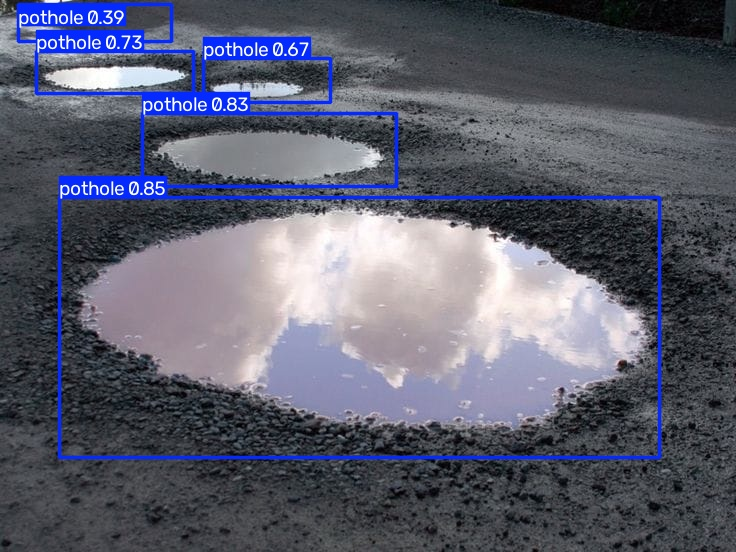

In [7]:
from IPython.display import Image,display
import glob

result_image = glob.glob("/content/runs/detect/predict/*")[0]

display(Image(filename=result_image))

In [8]:
for i, result in enumerate(results):
    print(f"\nImage {i+1}")

    if result.boxes is not None and len(result.boxes) > 0:
        for j, box in enumerate(result.boxes):
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = float(box.conf[0])

            width = x2 - x1
            height = y2 - y1

            print(f"Pothole {j+1}")
            print(f"Confidence: {confidence:.2f}")
            print(f"X1: {x1:.2f}, Y1: {y1:.2f}")
            print(f"X2: {x2:.2f}, Y2: {y2:.2f}")
            print(f"Width: {width:.2f} pixels")
            print(f"Height: {height:.2f} pixels")
    else:
        print("No pothole detected")


Image 1
Pothole 1
Confidence: 0.86
X1: 2.39, Y1: 314.61
X2: 623.81, Y2: 453.47
Width: 621.42 pixels
Height: 138.87 pixels
Pothole 2
Confidence: 0.56
X1: 0.00, Y1: 569.76
X2: 637.66, Y2: 640.00
Width: 637.66 pixels
Height: 70.24 pixels

Image 2
Pothole 1
Confidence: 0.90
X1: 80.93, Y1: 445.31
X2: 612.16, Y2: 899.42
Width: 531.23 pixels
Height: 454.11 pixels

Image 3
Pothole 1
Confidence: 0.85
X1: 59.60, Y1: 197.18
X2: 659.54, Y2: 457.96
Width: 599.94 pixels
Height: 260.78 pixels
Pothole 2
Confidence: 0.83
X1: 142.47, Y1: 113.23
X2: 396.49, Y2: 186.10
Width: 254.02 pixels
Height: 72.87 pixels
Pothole 3
Confidence: 0.73
X1: 36.47, Y1: 51.02
X2: 193.36, Y2: 93.15
Width: 156.90 pixels
Height: 42.13 pixels
Pothole 4
Confidence: 0.67
X1: 203.79, Y1: 58.23
X2: 330.26, Y2: 102.16
Width: 126.46 pixels
Height: 43.93 pixels
Pothole 5
Confidence: 0.39
X1: 18.85, Y1: 4.59
X2: 171.25, Y2: 41.42
Width: 152.40 pixels
Height: 36.84 pixels

Image 4
Pothole 1
Confidence: 0.89
X1: 116.27, Y1: 274.27
X2: 6

In [9]:
for i, result in enumerate(results):
    count = len(result.boxes)

    print(f"Image {i+1}: {count} pothole(s) detected")

Image 1: 2 pothole(s) detected
Image 2: 1 pothole(s) detected
Image 3: 5 pothole(s) detected
Image 4: 1 pothole(s) detected


In [10]:
normal_result = model.predict(
    source= "/content/normal_road.jpeg",
    conf= 0.25,
    save= True
)

print("Normal road test completed!")


image 1/1 /content/normal_road.jpeg: 640x480 1 pothole, 98.1ms
Speed: 4.4ms preprocess, 98.1ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict
Normal road test completed!


In [11]:
if len(normal_result[0].boxes) == 0:
    print("NO POTHOLE DETECTED ✅")
else:
    print(f"POTHOLE DETECTED: {len(normal_result[0].boxes)}")

POTHOLE DETECTED: 1


array([[[255, 246, 236],
        [255, 246, 236],
        [255, 246, 236],
        ...,
        [225, 216, 207],
        [225, 216, 207],
        [225, 216, 207]],

       [[255, 246, 236],
        [255, 246, 236],
        [255, 246, 236],
        ...,
        [225, 216, 207],
        [225, 216, 207],
        [225, 216, 207]],

       [[254, 245, 235],
        [254, 245, 235],
        [254, 245, 235],
        ...,
        [225, 216, 207],
        [225, 216, 207],
        [225, 216, 207]],

       ...,

       [[ 97, 102, 105],
        [ 99, 104, 107],
        [103, 108, 111],
        ...,
        [166, 192, 206],
        [166, 192, 206],
        [165, 191, 205]],

       [[ 97, 102, 105],
        [ 98, 103, 106],
        [101, 106, 109],
        ...,
        [167, 193, 207],
        [167, 193, 207],
        [166, 192, 206]],

       [[100, 105, 108],
        [ 98, 103, 106],
        [ 97, 102, 105],
        ...,
        [168, 194, 208],
        [167, 193, 207],
        [166, 192, 206]]], dtype=uint8)
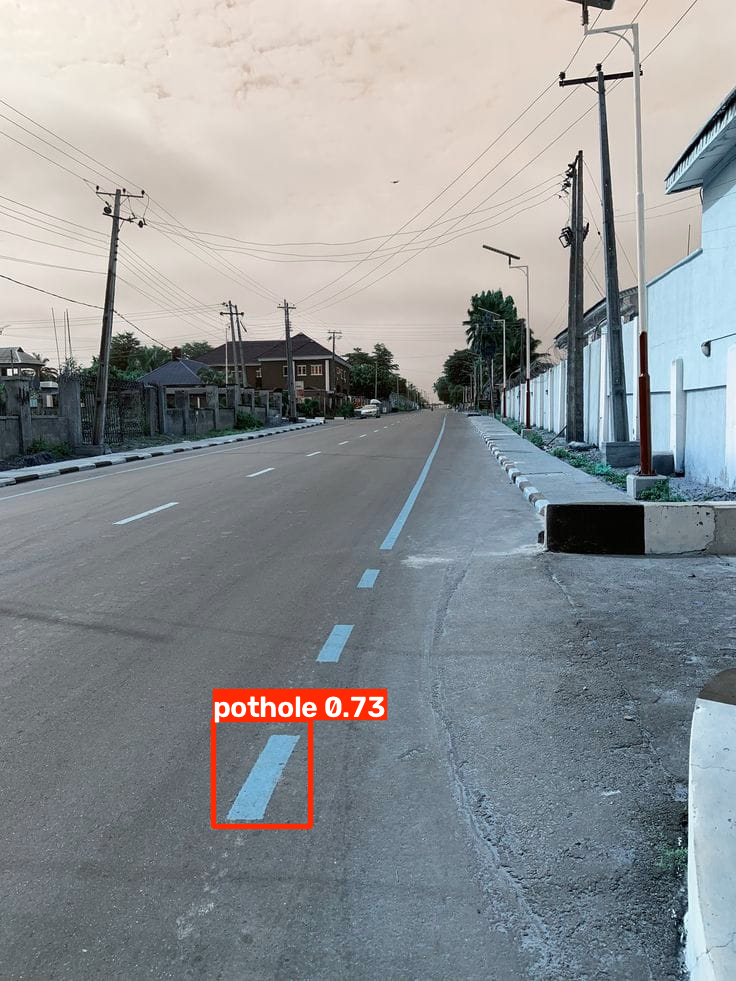

In [12]:
from IPython.display import display

display(normal_result[0].plot())

In [13]:
import zipfile
import os

zip_path = "/content/archive.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    files = zip_ref.namelist()

yaml_files = [f for f in files if f.endswith("data.yaml")]

print("data.yaml files found:")
for f in yaml_files:
    print(f)

data.yaml files found:
data.yaml


In [14]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/pothole_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [15]:
import os

for root, dirs, files in os.walk("/content/pothole_dataset"):
    for file in files:
        if file == "data.yaml":
            print("data.yaml found at:")
            print(os.path.join(root, file))

data.yaml found at:
/content/pothole_dataset/data.yaml


In [16]:
yaml_path = "/content/pothole_dataset/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['pothole']

roboflow:
  workspace: vasanthakumar662005
  project: pothole-pq3lu
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/vasanthakumar662005/pothole-pq3lu/dataset/1


In [17]:
import os

dataset_path = "/content/pothole_dataset"

print("Dataset exists:", os.path.exists(dataset_path))
print("Train folder:", os.path.exists(dataset_path + "/train/images"))
print("Valid folder:", os.path.exists(dataset_path + "/valid/images"))
print("Test folder:", os.path.exists(dataset_path + "/test/images"))

Dataset exists: True
Train folder: True
Valid folder: True
Test folder: True


In [18]:
import os

dataset_path = "/content/pothole_dataset"

for split in ["train", "valid", "test"]:
    image_folder = f"{dataset_path}/{split}/images"
    label_folder = f"{dataset_path}/{split}/labels"

    images = os.listdir(image_folder) if os.path.exists(image_folder) else []
    labels = os.listdir(label_folder) if os.path.exists(label_folder) else []

    print(f"\n{split.upper()}")
    print("Images:", len(images))
    print("Labels:", len(labels))


TRAIN
Images: 3345
Labels: 3345

VALID
Images: 397
Labels: 397

TEST
Images: 198
Labels: 198


In [19]:
from ultralytics import YOLO

model = YOLO("/content/best.pt")

results = model.predict(
    source="/content/pothole_dataset/test/images",
    conf=0.25,
    save=True
)

print("Test dataset detection completed!")


image 1/198 /content/pothole_dataset/test/images/101_jpg.rf.ac03d0fc729e1fbbafb070d2ea30c9d9.jpg: 640x640 1 pothole, 7.8ms
image 2/198 /content/pothole_dataset/test/images/111_jpg.rf.019e079da16b88cda78be0fc63c5de9c.jpg: 640x640 1 pothole, 11.3ms
image 3/198 /content/pothole_dataset/test/images/114_jpg.rf.231877c4cda184b915d7bbce1fad65a8.jpg: 640x640 2 potholes, 7.8ms
image 4/198 /content/pothole_dataset/test/images/117_jpg.rf.88fe8affec70765d35e71369f1853158.jpg: 640x640 1 pothole, 7.8ms
image 5/198 /content/pothole_dataset/test/images/117_jpg.rf.f1f690cbe9439f8606ae3f441fd3dd60.jpg: 640x640 2 potholes, 7.8ms
image 6/198 /content/pothole_dataset/test/images/121_jpg.rf.c99f70bf6a3130d9e61ac02686779392.jpg: 640x640 (no detections), 7.8ms
image 7/198 /content/pothole_dataset/test/images/128_jpg.rf.ff27168c3437b5fc7653f15c50e72661.jpg: 640x640 3 potholes, 7.8ms
image 8/198 /content/pothole_dataset/test/images/135_jpg.rf.9d0d6f3e6bc848cebb6f2ea6a239f2c9.jpg: 640x640 1 pothole, 7.8ms
image

In [20]:
metrics = model.val(
    data="/content/pothole_dataset/data.yaml",
    split="test"
)

print("Validation completed!")

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1282.7±424.4 MB/s, size: 59.9 KB)
val: Scanning /content/pothole_dataset/test/labels... 198 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 2.2Kit/s 0.1s
val: New cache created: /content/pothole_dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 3.0it/s 4.3s
                   all        198        433      0.902      0.859      0.925      0.643
Speed: 3.1ms preprocess, 4.7ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/val
Validation completed!


In [21]:
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Precision: 0.9019104646457855
Recall: 0.859122401847575
mAP50: 0.9247284888477115
mAP50-95: 0.6429310160322601


In [22]:
import os

print("Files generated during evaluation:")

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "confusion" in file.lower() or file in [
            "results.png",
            "PR_curve.png",
            "F1_curve.png"
        ]:
            print(os.path.join(root, file))

Files generated during evaluation:
/content/runs/detect/val/confusion_matrix_normalized.png
/content/runs/detect/val/confusion_matrix.png


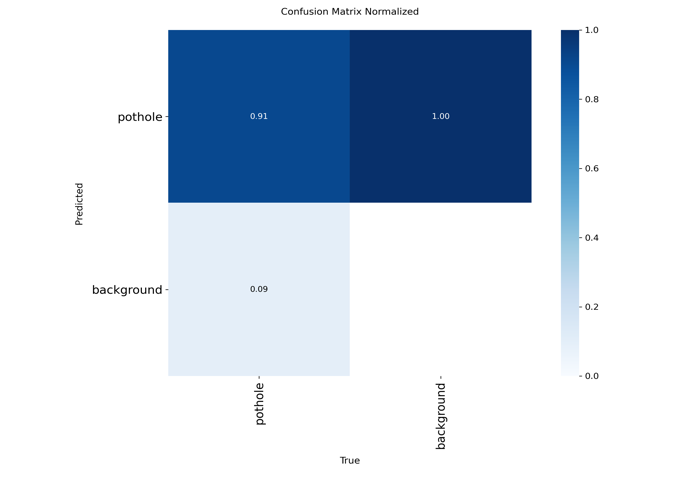

In [23]:
from IPython.display import display
from PIL import Image

img = Image.open("/content/runs/detect/val/confusion_matrix_normalized.png")
display(img.resize((700, 500)))

In [24]:
import os

folder = "/content/runs/detect/val"

print("Evaluation files:")
for file in os.listdir(folder):
    print(file)

Evaluation files:
val_batch0_labels.jpg
val_batch1_pred.jpg
BoxP_curve.png
BoxF1_curve.png
BoxPR_curve.png
confusion_matrix_normalized.png
val_batch2_pred.jpg
val_batch1_labels.jpg
BoxR_curve.png
val_batch2_labels.jpg
confusion_matrix.png
val_batch0_pred.jpg


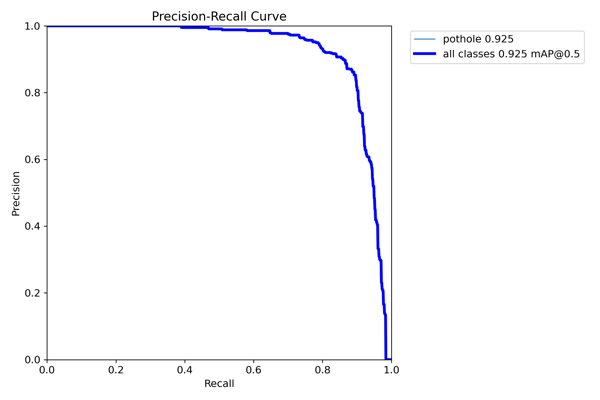

In [25]:
from IPython.display import display
from PIL import Image

img = Image.open("/content/runs/detect/val/BoxPR_curve.png")

display(img.resize((600, 400)))

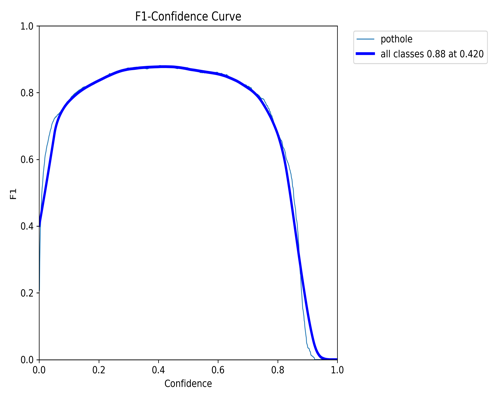

In [26]:
from IPython.display import display
from PIL import Image

img = Image.open("/content/runs/detect/val/BoxF1_curve.png")
display(img.resize((500, 400)))

In [27]:
image_paths = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg",
    "/content/normal_road.jpeg"
]

final_results = model.predict(
    source=image_paths,
    conf=0.42,
    save=True
)

print("Final testing completed!")


0: 640x640 2 potholes, 9.6ms
1: 640x640 1 pothole, 9.6ms
2: 640x640 4 potholes, 9.6ms
3: 640x640 1 pothole, 9.6ms
4: 640x640 1 pothole, 9.6ms
Speed: 1.5ms preprocess, 9.6ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict-2
Final testing completed!


In [28]:
for i, result in enumerate(final_results):
    count = len(result.boxes)
    print(f"Image {i+1}: {count} pothole(s) detected")

Image 1: 2 pothole(s) detected
Image 2: 1 pothole(s) detected
Image 3: 4 pothole(s) detected
Image 4: 1 pothole(s) detected
Image 5: 1 pothole(s) detected


In [29]:
result = model.predict(
    source="/content/normal_road.jpeg",
    conf=0.05,
    verbose=False
)[0]

if result.boxes is not None and len(result.boxes) > 0:
    for i, box in enumerate(result.boxes):
        confidence = float(box.conf[0])
        print(f"Detection {i+1}: Confidence = {confidence:.3f}")
else:
    print("No pothole detected")

Detection 1: Confidence = 0.733
Detection 2: Confidence = 0.223
Detection 3: Confidence = 0.103


In [30]:
result = model.predict(
    source="/content/normal_road.jpeg",
    conf=0.75,
    verbose=False
)[0]

if result.boxes is not None and len(result.boxes) > 0:
    for i, box in enumerate(result.boxes):
        confidence = float(box.conf[0])
        print(f"Detection {i+1}: Confidence = {confidence:.3f}")
else:
    print("No pothole detected")

No pothole detected


In [31]:
pothole_images = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg"
]

pothole_results = model.predict(
    source=pothole_images,
    conf=0.75,
    verbose=False
)

for i, result in enumerate(pothole_results):
    count = len(result.boxes)
    print(f"Image {i+1}: {count} pothole(s) detected")

    if count > 0:
        for j, box in enumerate(result.boxes):
            confidence = float(box.conf[0])
            print(f"   Pothole {j+1}: {confidence:.3f}")

Image 1: 1 pothole(s) detected
   Pothole 1: 0.864
Image 2: 1 pothole(s) detected
   Pothole 1: 0.900
Image 3: 2 pothole(s) detected
   Pothole 1: 0.845
   Pothole 2: 0.830
Image 4: 1 pothole(s) detected
   Pothole 1: 0.886


In [32]:
metrics_075 = model.val(
    data="/content/pothole_dataset/data.yaml",
    split="test",
    conf=0.75
)

print("Precision:", metrics_075.box.mp)
print("Recall:", metrics_075.box.mr)
print("mAP50:", metrics_075.box.map50)
print("mAP50-95:", metrics_075.box.map)

Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1610.8±850.5 MB/s, size: 50.0 KB)
val: Scanning /content/pothole_dataset/test/labels.cache... 198 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 59.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.0it/s 3.3s
                   all        198        433      0.979      0.649      0.642      0.477
Speed: 2.8ms preprocess, 4.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-2
Precision: 0.9790940766550522
Recall: 0.648960739030023
mAP50: 0.6424838152382367
mAP50-95: 0.47702417618733106


===== POTHOLE DETECTION RESULT =====
Potholes detected: 1

Pothole 1
Confidence: 0.86
Width: 621.42 pixels
Height: 138.87 pixels


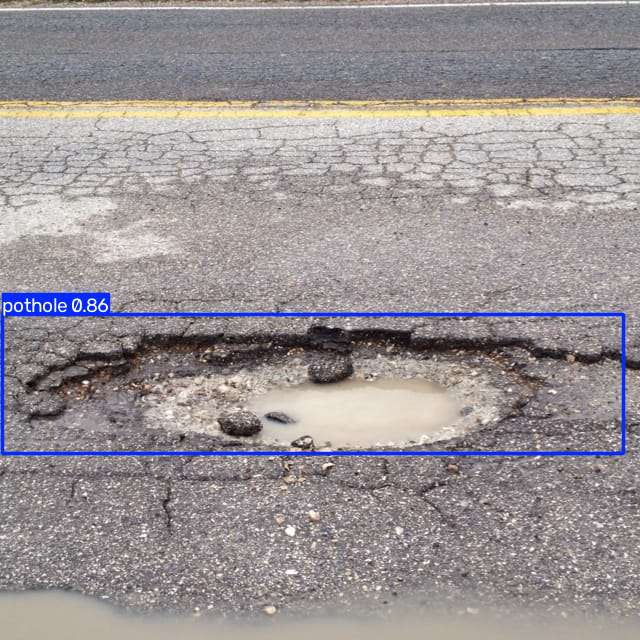

In [33]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

# Load trained model
model = YOLO("/content/best.pt")

# Input image
image_path = "/content/pothole_01.jpeg"

# Detect potholes
result = model.predict(
    source=image_path,
    conf=0.75,
    verbose=False
)[0]

# Number of potholes
count = len(result.boxes)

print("===== POTHOLE DETECTION RESULT =====")
print("Potholes detected:", count)

if count > 0:
    for i, box in enumerate(result.boxes):
        confidence = float(box.conf[0])

        x1, y1, x2, y2 = box.xyxy[0].tolist()
        width = x2 - x1
        height = y2 - y1

        print(f"\nPothole {i+1}")
        print(f"Confidence: {confidence:.2f}")
        print(f"Width: {width:.2f} pixels")
        print(f"Height: {height:.2f} pixels")
else:
    print("No pothole detected")

# Display result
display(Image.fromarray(result.plot()[:, :, ::-1]))

In [34]:
import os
from ultralytics import YOLO

model = YOLO("/content/best.pt")

image_paths = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg",
    "/content/normal_road.jpeg"
]

results = model.predict(
    source=image_paths,
    conf=0.75,
    save=True,
    project="/content/final_detection",
    name="results",
    exist_ok=True,
    verbose=False
)

print("===== FINAL TESTING =====")

for i, result in enumerate(results):
    count = len(result.boxes)
    print(f"Image {i+1}: {count} pothole(s) detected")

print("\nResults saved at:")
print("/content/final_detection/results")

Results saved to /content/final_detection/results
===== FINAL TESTING =====
Image 1: 1 pothole(s) detected
Image 2: 1 pothole(s) detected
Image 3: 2 pothole(s) detected
Image 4: 1 pothole(s) detected
Image 5: 0 pothole(s) detected

Results saved at:
/content/final_detection/results



 normal_road.jpg


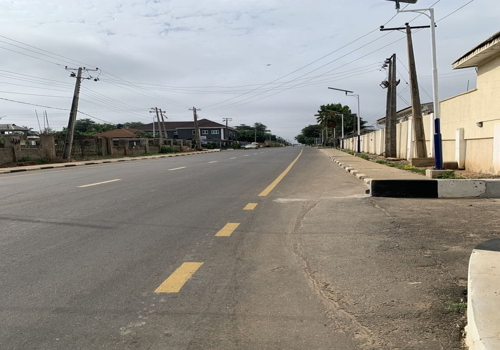


 pothole_01.jpg


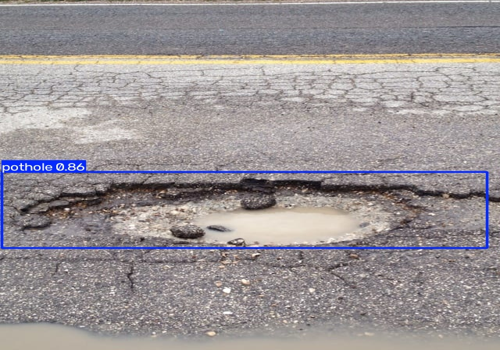


 pothole_02.jpg


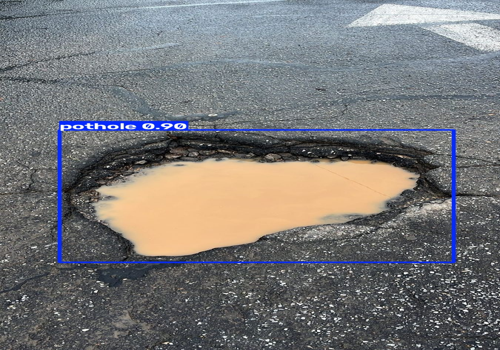


 pothole_03.jpg


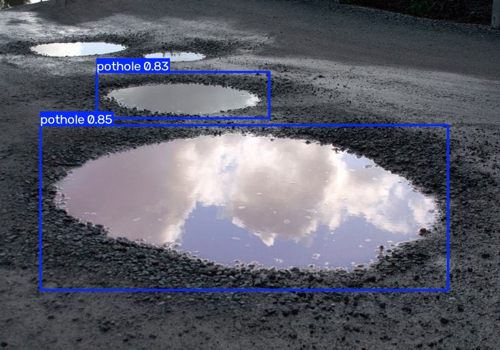


 pothole_04.jpg


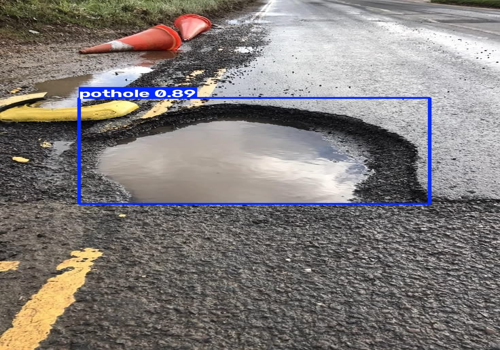

In [35]:
from IPython.display import display
from PIL import Image
import os

folder = "/content/final_detection/results"

for file in sorted(os.listdir(folder)):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        print("\n", file)
        display(Image.open(os.path.join(folder, file)).resize((500, 350)))

In [36]:
result = model.predict(
    source="/content/pothole_03.jpeg",
    conf=0.05,
    verbose=False
)[0]

print("Detections in Image 3:")

for i, box in enumerate(result.boxes):
    confidence = float(box.conf[0])
    print(f"Pothole {i+1}: Confidence = {confidence:.3f}")

Detections in Image 3:
Pothole 1: Confidence = 0.882
Pothole 2: Confidence = 0.871
Pothole 3: Confidence = 0.741
Pothole 4: Confidence = 0.681


In [37]:
test_images = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg",
    "/content/normal_road.jpeg"
]

results_070 = model.predict(
    source=test_images,
    conf=0.70,
    verbose=False
)

for i, result in enumerate(results_070):
    print(f"Image {i+1}: {len(result.boxes)} pothole(s) detected")

Image 1: 1 pothole(s) detected
Image 2: 1 pothole(s) detected
Image 3: 3 pothole(s) detected
Image 4: 1 pothole(s) detected
Image 5: 1 pothole(s) detected


In [38]:
import csv
import os

image_paths = [
    "/content/pothole_01.jpeg",
    "/content/pothole_02.jpeg",
    "/content/pothole_03.jpeg",
    "/content/pothole_04.jpeg",
    "/content/normal_road.jpeg"
]

results = model.predict(
    source=image_paths,
    conf=0.42,
    verbose=False
)

csv_path = "/content/pothole_detection_results.csv"

with open(csv_path, "w", newline="") as file:
    writer = csv.writer(file)

    writer.writerow([
        "Image",
        "Pothole_ID",
        "Confidence",
        "X1",
        "Y1",
        "X2",
        "Y2",
        "Width_pixels",
        "Height_pixels"
    ])

    for image_path, result in zip(image_paths, results):

        image_name = os.path.basename(image_path)

        for i, box in enumerate(result.boxes):

            x1, y1, x2, y2 = box.xyxy[0].tolist()
            confidence = float(box.conf[0])

            width = x2 - x1
            height = y2 - y1

            writer.writerow([
                image_name,
                i + 1,
                round(confidence, 3),
                round(x1, 2),
                round(y1, 2),
                round(x2, 2),
                round(y2, 2),
                round(width, 2),
                round(height, 2)
            ])

print("Results saved successfully!")
print(csv_path)

Results saved successfully!
/content/pothole_detection_results.csv


In [39]:
!pip install folium

In [40]:
import folium

# Simulated GPS locations for project demonstration
pothole_locations = [
    {
        "name": "Pothole 1",
        "lat": 21.1458,
        "lon": 79.0882,
        "confidence": 0.86
    },
    {
        "name": "Pothole 2",
        "lat": 21.1465,
        "lon": 79.0890,
        "confidence": 0.90
    },
    {
        "name": "Pothole 3",
        "lat": 21.1472,
        "lon": 79.0875,
        "confidence": 0.84
    },
    {
        "name": "Pothole 4",
        "lat": 21.1449,
        "lon": 79.0901,
        "confidence": 0.88
    }
]

# Create map
pothole_map = folium.Map(
    location=[21.1460, 79.0885],
    zoom_start=15
)

# Add pothole markers
for pothole in pothole_locations:

    popup_text = f"""
    <b>{pothole['name']}</b><br>
    Confidence: {pothole['confidence']:.2f}<br>
    Latitude: {pothole['lat']}<br>
    Longitude: {pothole['lon']}
    """

    folium.Marker(
        location=[pothole["lat"], pothole["lon"]],
        popup=popup_text,
        tooltip=pothole["name"]
    ).add_to(pothole_map)

# Save map
map_path = "/content/pothole_map.html"
pothole_map.save(map_path)

print("Map created successfully!")
print("Saved at:", map_path)

pothole_map

Map created successfully!
Saved at: /content/pothole_map.html


In [41]:
import sqlite3

# Create database
conn = sqlite3.connect("/content/pothole_database.db")
cursor = conn.cursor()

# Create potholes table
cursor.execute("""
CREATE TABLE IF NOT EXISTS potholes (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    latitude REAL,
    longitude REAL,
    confidence REAL,
    width_pixels REAL,
    height_pixels REAL,
    image_name TEXT,
    detected_at TEXT
)
""")

conn.commit()

print("Database created successfully!")
print("Table 'potholes' created successfully!")

conn.close()

Database created successfully!
Table 'potholes' created successfully!


In [42]:
import sqlite3
from datetime import datetime

# Connect to database
conn = sqlite3.connect("/content/pothole_database.db")
cursor = conn.cursor()

# Demo GPS locations
locations = [
    (21.1458, 79.0882),
    (21.1465, 79.0890),
    (21.1472, 79.0875),
    (21.1449, 79.0901)
]

# Insert pothole records
for i, (lat, lon) in enumerate(locations):

    cursor.execute("""
    INSERT INTO potholes
    (latitude, longitude, confidence, width_pixels,
     height_pixels, image_name, detected_at)
    VALUES (?, ?, ?, ?, ?, ?, ?)
    """, (
        lat,
        lon,
        0.86,                 # demo confidence
        620.0,                # demo width
        140.0,                # demo height
        f"pothole_{i+1}.jpeg",
        datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    ))

conn.commit()

print("Pothole data inserted successfully!")

conn.close()

Pothole data inserted successfully!


In [43]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/content/pothole_database.db")

df = pd.read_sql_query(
    "SELECT * FROM potholes",
    conn
)

conn.close()

print("Total pothole records:", len(df))
df

Total pothole records: 4


,id,latitude,longitude,confidence,width_pixels,height_pixels,image_name,detected_at
0,1,21.1458,79.0882,0.86,620.0,140.0,pothole_1.jpeg,2026-09-06 09:59:58
1,2,21.1465,79.0890,0.86,620.0,140.0,pothole_2.jpeg,2026-09-06 09:59:58
2,3,21.1472,79.0875,0.86,620.0,140.0,pothole_3.jpeg,2026-09-06 09:59:58
3,4,21.1449,79.0901,0.86,620.0,140.0,pothole_4.jpeg,2026-09-06 09:59:58


In [44]:
import sqlite3
import folium

# Connect to database
conn = sqlite3.connect("/content/pothole_database.db")
cursor = conn.cursor()

# Fetch pothole locations
cursor.execute("""
SELECT id, latitude, longitude, confidence, image_name
FROM potholes
""")

potholes = cursor.fetchall()
conn.close()

# Create map
pothole_map = folium.Map(
    location=[21.1460, 79.0885],
    zoom_start=15
)

# Add database records to map
for pothole in potholes:

    pothole_id, lat, lon, confidence, image_name = pothole

    popup = f"""
    <b>Pothole ID:</b> {pothole_id}<br>
    <b>Confidence:</b> {confidence:.2f}<br>
    <b>Image:</b> {image_name}<br>
    <b>Latitude:</b> {lat}<br>
    <b>Longitude:</b> {lon}
    """

    folium.Marker(
        location=[lat, lon],
        popup=popup,
        tooltip=f"Pothole {pothole_id}"
    ).add_to(pothole_map)

# Save updated map
map_path = "/content/database_pothole_map.html"
pothole_map.save(map_path)

print("Database-connected map created successfully!")
print("Total potholes mapped:", len(potholes))
print("Map saved at:", map_path)

pothole_map

Database-connected map created successfully!
Total potholes mapped: 4
Map saved at: /content/database_pothole_map.html


In [45]:
import sqlite3
import pandas as pd

# Connect to database
conn = sqlite3.connect("/content/pothole_database.db")

df = pd.read_sql_query(
    "SELECT * FROM potholes",
    conn
)

conn.close()

# Create HTML dashboard
html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>AI Based Pothole Detection</title>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 20px;
            background: #f4f4f4;
        }}

        h1 {{
            text-align: center;
        }}

        .card {{
            background: white;
            padding: 20px;
            margin: 20px auto;
            max-width: 900px;
            border-radius: 10px;
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
        }}

        th, td {{
            padding: 10px;
            border: 1px solid #ddd;
            text-align: center;
        }}

        th {{
            background: #333;
            color: white;
        }}
    </style>
</head>

<body>

<h1>AI Based Pothole Detection & Web Mapping System</h1>

<div class="card">
    <h2>Detection Summary</h2>
    <h3>Total Potholes Detected: {len(df)}</h3>
</div>

<div class="card">
    <h2>Pothole Records</h2>

    {df.to_html(index=False)}
</div>

</body>
</html>
"""

dashboard_path = "/content/pothole_dashboard.html"

with open(dashboard_path, "w") as file:
    file.write(html)

print("Dashboard created successfully!")
print("Saved at:", dashboard_path)

Dashboard created successfully!
Saved at: /content/pothole_dashboard.html


In [46]:
import sqlite3
import pandas as pd
import folium

# -----------------------------
# 1. Read database
# -----------------------------
conn = sqlite3.connect("/content/pothole_database.db")

df = pd.read_sql_query(
    "SELECT * FROM potholes",
    conn
)

conn.close()

# -----------------------------
# 2. Create map
# -----------------------------
pothole_map = folium.Map(
    location=[21.1460, 79.0885],
    zoom_start=15
)

for _, row in df.iterrows():

    popup = f"""
    <b>Pothole ID:</b> {row['id']}<br>
    <b>Confidence:</b> {row['confidence']:.2f}<br>
    <b>Image:</b> {row['image_name']}<br>
    <b>Latitude:</b> {row['latitude']}<br>
    <b>Longitude:</b> {row['longitude']}
    """

    folium.Marker(
        location=[row["latitude"], row["longitude"]],
        popup=popup,
        tooltip=f"Pothole {row['id']}"
    ).add_to(pothole_map)

# Get map HTML
map_html = pothole_map.get_root().render()

# -----------------------------
# 3. Create dashboard
# -----------------------------
table_html = df.to_html(index=False)

dashboard_html = f"""
<!DOCTYPE html>
<html>
<head>
    <title>AI Based Pothole Detection</title>

    <style>
        body {{
            font-family: Arial, sans-serif;
            margin: 0;
            padding: 20px;
            background: #f4f4f4;
        }}

        h1 {{
            text-align: center;
        }}

        .card {{
            background: white;
            padding: 20px;
            margin: 20px auto;
            max-width: 1100px;
            border-radius: 10px;
        }}

        iframe {{
            width: 100%;
            height: 500px;
            border: none;
        }}

        table {{
            width: 100%;
            border-collapse: collapse;
        }}

        th, td {{
            padding: 8px;
            border: 1px solid #ddd;
            text-align: center;
        }}

        th {{
            background: #333;
            color: white;
        }}
    </style>
</head>

<body>

<h1>AI Based Pothole Detection & Web Mapping System</h1>

<div class="card">
    <h2>Detection Summary</h2>
    <h3>Total Pothole Records: {len(df)}</h3>
</div>

<div class="card">
    <h2>Pothole Map</h2>

    <iframe
        srcdoc='{map_html.replace("'", "&apos;")}'>
    </iframe>
</div>

<div class="card">
    <h2>Pothole Detection Records</h2>

    {table_html}
</div>

</body>
</html>
"""

# -----------------------------
# 4. Save final dashboard
# -----------------------------
dashboard_path = "/content/final_pothole_dashboard.html"

with open(dashboard_path, "w", encoding="utf-8") as file:
    file.write(dashboard_html)

print("================================")
print("FINAL DASHBOARD CREATED!")
print("================================")
print("Total records:", len(df))
print("Saved at:", dashboard_path)

FINAL DASHBOARD CREATED!
Total records: 4
Saved at: /content/final_pothole_dashboard.html


In [48]:
from IPython.display import HTML, display

with open("/content/final_pothole_dashboard.html", "r", encoding="utf-8") as f:
    dashboard = f.read()

display(HTML(dashboard))

id,latitude,longitude,confidence,width_pixels,height_pixels,image_name,detected_at
1,21.1458,79.0882,0.86,620.0,140.0,pothole_1.jpeg,2026-09-06 09:59:58
2,21.1465,79.0890,0.86,620.0,140.0,pothole_2.jpeg,2026-09-06 09:59:58
3,21.1472,79.0875,0.86,620.0,140.0,pothole_3.jpeg,2026-09-06 09:59:58
4,21.1449,79.0901,0.86,620.0,140.0,pothole_4.jpeg,2026-09-06 09:59:58
